# NLP Project: Disaster Tweet Classification

**Objective:** Build, evaluate, and deploy a machine learning model that classifies tweets as either about a **real disaster (1)** or **not a real disaster (0)**.

This notebook follows the four parts of the project brief:

1. **Data Exploration and Preparation**
2. **Feature Engineering and Model Selection**
3. **Model Evaluation and Validation**
4. **Deployment with Web Interface** (built separately as a Flask app — see `/app`)

Dataset: `twitter_disaster.csv` — 7,613 hand-labeled tweets with columns `id, keyword, location, text, target`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


ModuleNotFoundError: No module named 'wordcloud'

## Part 1: Data Exploration and Preparation

### 1.1 Load the dataset

In [ ]:
df = pd.read_csv('../data/twitter_disaster.csv')
print("Shape:", df.shape)
df.head(10)


Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,1
6,10,NaN,NaN,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in the woods...,1
8,14,NaN,NaN,There's an emergency evacuation happening now in the building across the street,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our area...,1


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


### 1.2 Explore structure, missing values, and duplicates

In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate tweet texts:", df.duplicated(subset=['text']).sum())


Missing values per column:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Duplicate rows: 0
Duplicate tweet texts: 110


In [ ]:
# 'keyword' and 'location' have missing values -- expected for free-text tweets.
# We'll keep 'keyword' as an optional engineered feature and drop 'location' (too sparse/noisy
# and not consistently formatted -- e.g. 'USA', 'usa', 'New York, NY' all mean different things).
df['keyword'] = df['keyword'].fillna('none')
print(df['keyword'].nunique(), "unique keyword values (including 'none')")


222 unique keyword values (including 'none')


### 1.3 Class distribution (disaster vs non-disaster)

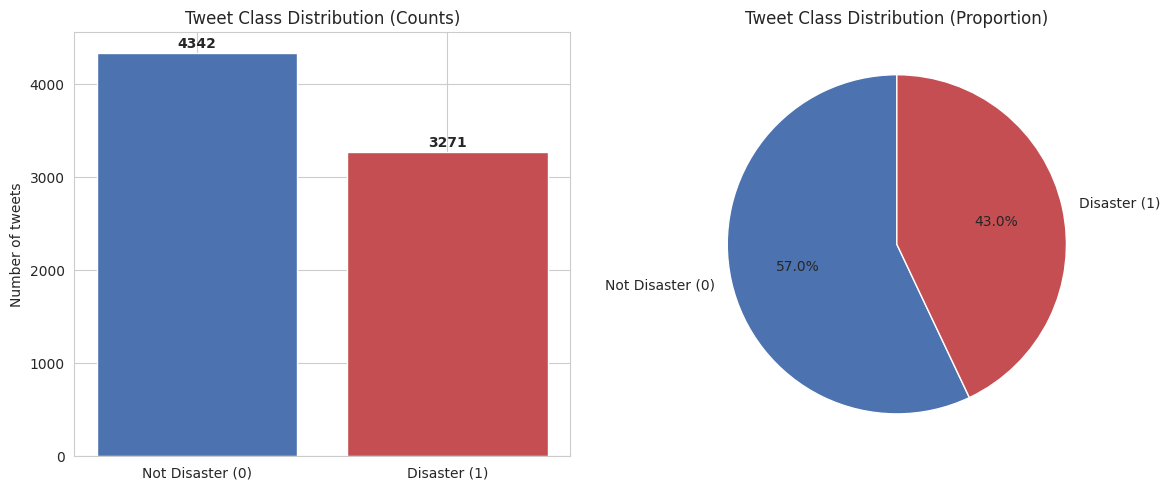

Non-disaster: 4342 (57.0%)
Disaster:     3271 (43.0%)

The dataset is only mildly imbalanced (~57% / 43%), so we do not need aggressive
resampling, but we will still use 'stratify' during train/test splitting and report
precision/recall/F1 (not just accuracy) since disaster detection is a safety-critical task.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts().sort_index()
labels = ['Not Disaster (0)', 'Disaster (1)']
axes[0].bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Tweet Class Distribution (Counts)')
axes[0].set_ylabel('Number of tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'],
            startangle=90)
axes[1].set_title('Tweet Class Distribution (Proportion)')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

print(f"Non-disaster: {counts[0]} ({counts[0]/len(df):.1%})")
print(f"Disaster:     {counts[1]} ({counts[1]/len(df):.1%})")
print("\nThe dataset is only mildly imbalanced (~57% / 43%), so we do not need aggressive")
print("resampling, but we will still use 'stratify' during train/test splitting and report")
print("precision/recall/F1 (not just accuracy) since disaster detection is a safety-critical task.")


### 1.4 Tweet length analysis

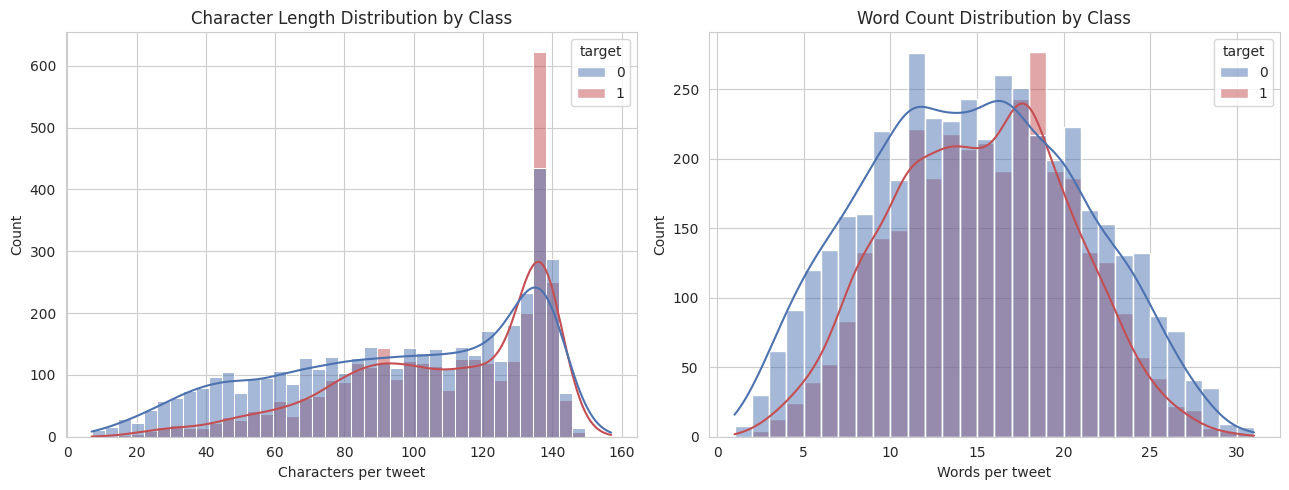

target                      0            1
char_len   count  4342.000000  3271.000000
           mean     95.706817   108.113421
           std      35.885924    29.309854
           min       7.000000    14.000000
           25%      68.000000    88.000000
           50%     101.000000   115.000000
           75%     130.000000   136.000000
           max     157.000000   151.000000
word_count count  4342.000000  3271.000000
           mean     14.704744    15.167533
           std       6.161564     5.096806
           min       1.000000     2.000000
           25%      10.000000    11.000000
           50%      15.000000    15.000000
           75%      19.000000    19.000000
           max      31.000000    30.000000

In [ ]:
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=df, x='char_len', hue='target', bins=40, kde=True, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Character Length Distribution by Class')
axes[0].set_xlabel('Characters per tweet')

sns.histplot(data=df, x='word_count', hue='target', bins=30, kde=True, ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Word Count Distribution by Class')
axes[1].set_xlabel('Words per tweet')

plt.tight_layout()
plt.savefig('../reports/length_distribution.png', dpi=150)
plt.show()

df.groupby('target')[['char_len', 'word_count']].describe().T


### 1.5 Most frequent keywords in disaster vs non-disaster tweets

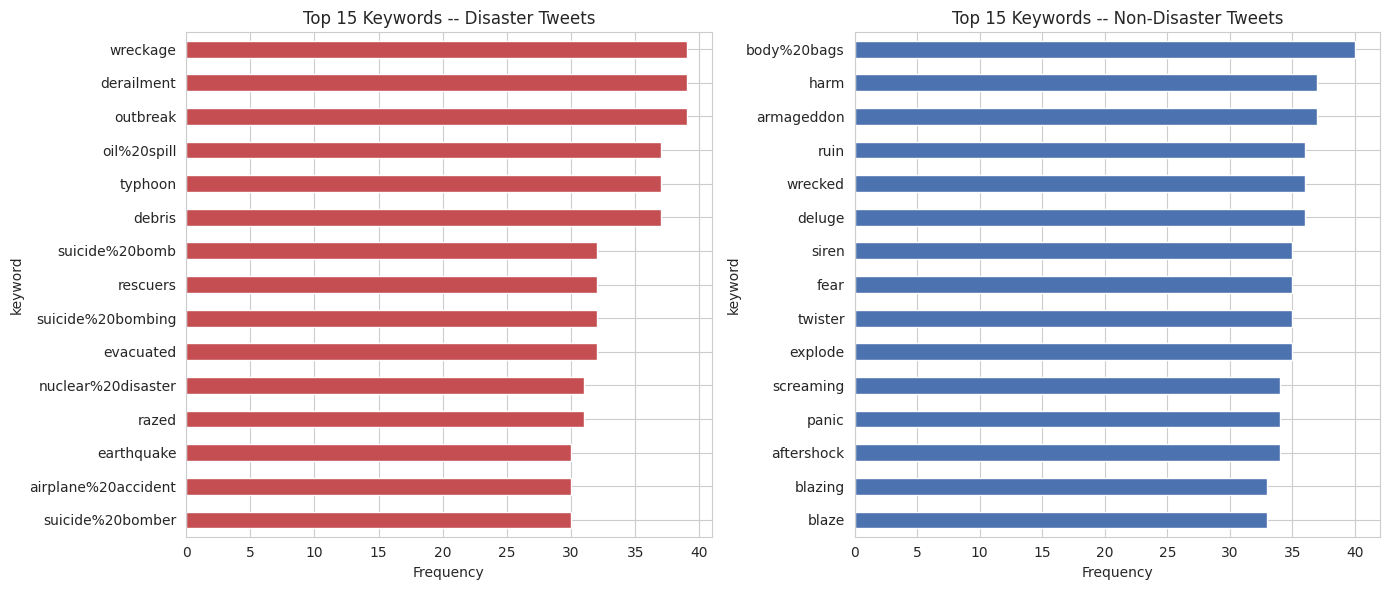

In [ ]:
top_disaster_kw = (df[(df['target'] == 1) & (df['keyword'] != 'none')]['keyword']
                   .value_counts().head(15))
top_nondisaster_kw = (df[(df['target'] == 0) & (df['keyword'] != 'none')]['keyword']
                      .value_counts().head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_disaster_kw.sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Top 15 Keywords -- Disaster Tweets')
axes[0].set_xlabel('Frequency')

top_nondisaster_kw.sort_values().plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 15 Keywords -- Non-Disaster Tweets')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/keyword_frequency.png', dpi=150)
plt.show()


In [ ]:
# Keywords that appear almost exclusively in ONE class -- highly predictive signal
kw_target_rate = (df[df['keyword'] != 'none'].groupby('keyword')['target']
                   .agg(['mean', 'count']))
kw_target_rate = kw_target_rate[kw_target_rate['count'] >= 20].sort_values('mean')
print("Keywords most associated with NON-disaster tweets (low disaster rate):")
print(kw_target_rate.head(8))
print("\nKeywords most associated with DISASTER tweets (high disaster rate):")
print(kw_target_rate.tail(8))


Keywords most associated with NON-disaster tweets (low disaster rate):
                 mean  count
keyword                     
aftershock   0.000000     34
body%20bags  0.024390     41
ruin         0.027027     37
blazing      0.029412     34
body%20bag   0.030303     33
electrocute  0.031250     32
screaming    0.055556     36
traumatised  0.057143     35

Keywords most associated with DISASTER tweets (high disaster rate):
                       mean  count
keyword                           
suicide%20bomber   0.967742     31
suicide%20bombing  0.969697     33
typhoon            0.973684     38
oil%20spill        0.973684     38
outbreak           0.975000     40
debris             1.000000     37
derailment         1.000000     39
wreckage           1.000000     39


This confirms the challenge described in the brief: words like **"wrecked"** or **"body%20bags"** are often used *metaphorically* ('this exam wrecked me') while words like **"derailment"** or **"debris"** almost always signal a real disaster. A model relying only on keyword-matching would fail -- we need the surrounding context, which is exactly what TF-IDF + n-grams and word embeddings capture.

### 1.6 Word clouds -- most common words per class

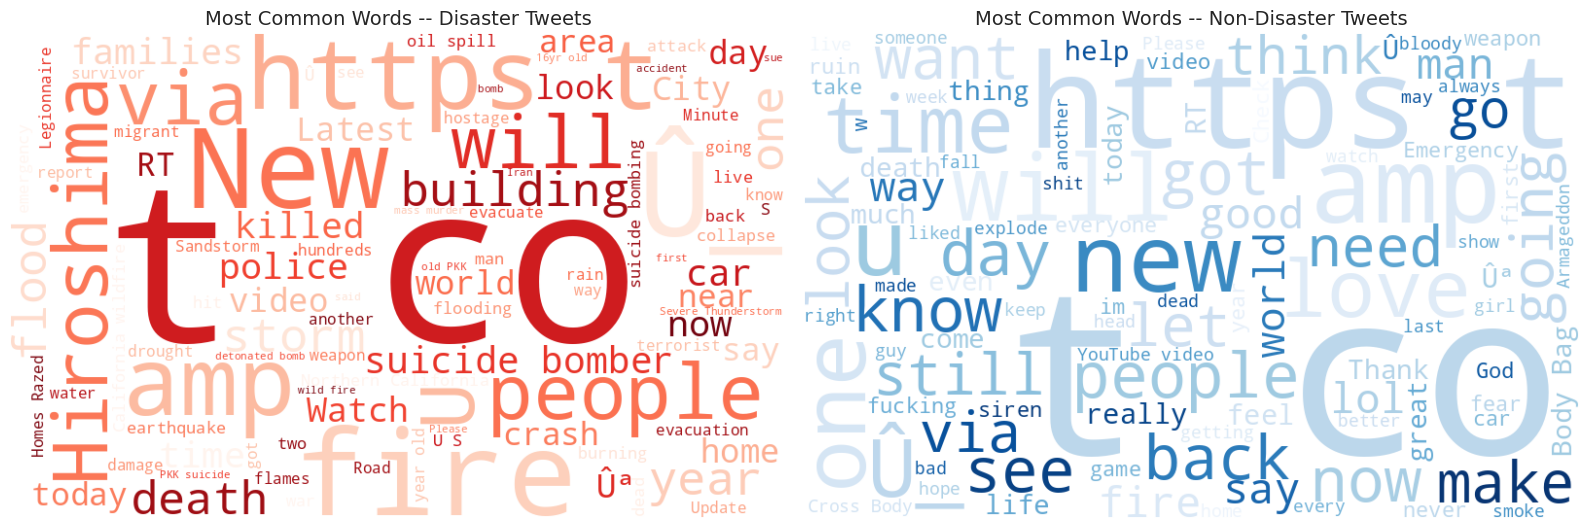

In [ ]:
def build_wordcloud_text(series):
    return ' '.join(series.astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc1 = WordCloud(width=800, height=500, background_color='white', colormap='Reds',
                max_words=100).generate(build_wordcloud_text(df[df.target==1]['text']))
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('Most Common Words -- Disaster Tweets', fontsize=14)
axes[0].axis('off')

wc0 = WordCloud(width=800, height=500, background_color='white', colormap='Blues',
                max_words=100).generate(build_wordcloud_text(df[df.target==0]['text']))
axes[1].imshow(wc0, interpolation='bilinear')
axes[1].set_title('Most Common Words -- Non-Disaster Tweets', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/wordclouds.png', dpi=150)
plt.show()


## Data Preparation

We now clean and normalize the raw tweet text:
- Lowercase
- Remove URLs, HTML entities, mentions (`@user`), hashtags symbol (keep the word), numbers, punctuation
- Remove stopwords
- Lemmatize tokens
- Tokenize


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r'https?://\S+|www\.\S+')
HTML_RE = re.compile(r'&[a-z]+;')
MENTION_RE = re.compile(r'@\w+')
NON_ALPHA_RE = re.compile(r'[^a-zA-Z\s]')

def clean_text(text):
    text = text.lower()
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = text.replace('#', ' ')          # keep hashtag words, drop the symbol
    text = NON_ALPHA_RE.sub(' ', text)     # strip numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return tokens

df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize_and_lemmatize)
df['clean_joined'] = df['tokens'].apply(lambda t: ' '.join(t))

df[['text', 'clean_text', 'clean_joined']].head(10)


,text,clean_text,clean_joined
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,our deeds are the reason of this earthquake may allah forgive us all,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place order...,resident asked shelter place notified officer evacuation shelter place order expected
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders in california,people receive wildfire evacuation order california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent this photo from ruby alaska as smoke from wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy closed in both directions due to lake county fire cafire wildfires,rockyfire update california hwy closed direction due lake county fire cafire wildfire
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding of streets in manitou colorado springs areas,flood disaster heavy rain cause flash flooding street manitou colorado spring area
7,I'm on top of the hill and I can see a fire in the woods...,i m on top of the hill and i can see a fire in the woods,top hill see fire wood
8,There's an emergency evacuation happening now in the building across the street,there s an emergency evacuation happening now in the building across the street,emergency evacuation happening building across street
9,I'm afraid that the tornado is coming to our area...,i m afraid that the tornado is coming to our area,afraid tornado coming area


In [ ]:
# Extra engineered features (used later alongside TF-IDF)
df['has_hashtag'] = df['text'].str.contains('#').astype(int)
df['has_mention'] = df['text'].str.contains('@').astype(int)
df['has_url'] = df['text'].str.contains(r'https?://').astype(int)
df['exclaim_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')
df['uppercase_word_count'] = df['text'].apply(lambda t: sum(1 for w in t.split() if w.isupper() and len(w) > 1))

df[['has_hashtag', 'has_mention', 'has_url', 'exclaim_count', 'question_count', 'uppercase_word_count']].describe()


,has_hashtag,has_mention,has_url,exclaim_count,question_count,uppercase_word_count
count,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000
mean,0.231315,0.267831,0.521608,0.154079,0.410613,0.721792
std,0.421701,0.442858,0.499566,0.619387,1.833392,1.912798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,12.000000,54.000000,23.000000


### Convert labels to numeric format

The `target` column is already numeric (0 = non-disaster, 1 = disaster), matching the brief's requirement.

In [ ]:
print(df['target'].unique())
print(df['target'].dtype)


[1 0]
int64


### Train / test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['clean_joined', 'has_hashtag', 'has_mention', 'has_url',
        'exclaim_count', 'question_count', 'uppercase_word_count', 'word_count']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train size: 6090
Test size: 1523
Train class balance:
 target
0    0.570279
1    0.429721
Name: proportion, dtype: float64
Test class balance:
 target
0    0.570584
1    0.429416
Name: proportion, dtype: float64


## Part 2: Feature Engineering and Model Selection

### 2.1 Feature engineering: TF-IDF

We use **TF-IDF (Term Frequency-Inverse Document Frequency)** with uni-grams and bi-grams as the primary text representation. TF-IDF captures which words are distinctive to a document relative to the whole corpus -- much stronger than raw word counts for short, noisy text like tweets. We combine it with the small set of hand-crafted numeric features above (hashtags, mentions, punctuation counts, etc.) via a `ColumnTransformer`.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

TEXT_COL = 'clean_joined'
NUMERIC_COLS = ['has_hashtag', 'has_mention', 'has_url', 'exclaim_count',
                 'question_count', 'uppercase_word_count', 'word_count']

# MinMaxScaler (not StandardScaler) keeps the combined matrix non-negative --
# required because one candidate model, MultinomialNB, cannot accept negative values.
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                   min_df=2, sublinear_tf=True), TEXT_COL),
        ('num', MinMaxScaler(), NUMERIC_COLS),
    ]
)
print(preprocessor)


ColumnTransformer(transformers=[('tfidf',
                                 TfidfVectorizer(max_features=10000, min_df=2,
                                                 ngram_range=(1, 2),
                                                 sublinear_tf=True),
                                 'clean_joined'),
                                ('num', MinMaxScaler(),
                                 ['has_hashtag', 'has_mention', 'has_url',
                                  'exclaim_count', 'question_count',
                                  'uppercase_word_count', 'word_count'])])


### 2.2 Model selection and training

We train and compare four candidate classifiers commonly used for text classification:

1. **Logistic Regression** -- strong, fast, interpretable linear baseline for sparse TF-IDF features
2. **Multinomial Naive Bayes** -- classic, very fast text-classification baseline
3. **Random Forest** -- non-linear ensemble baseline
4. **Linear SVM (SGDClassifier with hinge loss)** -- typically among the best for sparse high-dimensional text

Each is wrapped in the same preprocessing pipeline and evaluated with **5-fold stratified cross-validation** on the training set (F1-score, since classes are imbalanced).


In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Linear SVM (SGD)': SGDClassifier(loss='hinge', random_state=RANDOM_STATE, max_iter=2000),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    start = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    elapsed = time.time() - start
    cv_results[name] = scores
    print(f"{name:28s}  F1 = {scores.mean():.4f} (+/- {scores.std():.4f})   [{elapsed:.1f}s]")


Logistic Regression           F1 = 0.7372 (+/- 0.0149)   [0.9s]


Multinomial Naive Bayes       F1 = 0.7216 (+/- 0.0148)   [0.7s]


Random Forest                 F1 = 0.7065 (+/- 0.0243)   [82.2s]


Linear SVM (SGD)              F1 = 0.7353 (+/- 0.0194)   [0.7s]


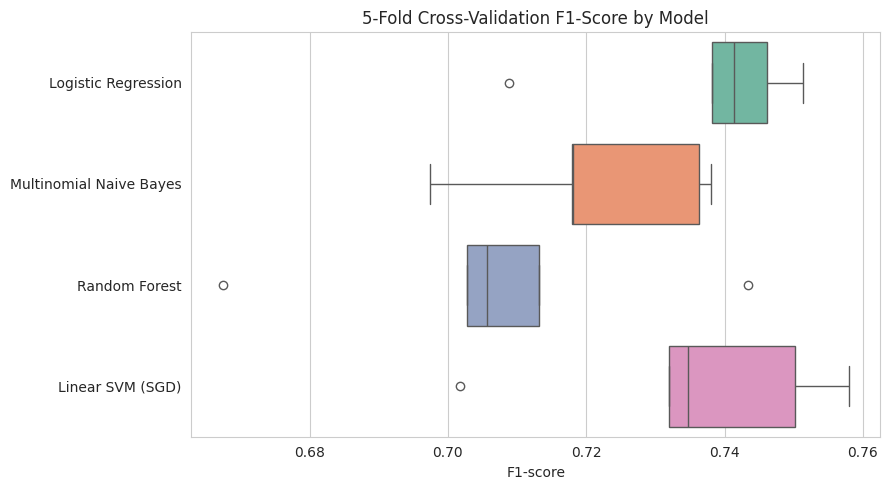

Logistic Regression        0.737160
Linear SVM (SGD)           0.735311
Multinomial Naive Bayes    0.721585
Random Forest              0.706489
dtype: float64

In [ ]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 5))
sns.boxplot(data=cv_df, orient='h', palette='Set2')
plt.title('5-Fold Cross-Validation F1-Score by Model')
plt.xlabel('F1-score')
plt.tight_layout()
plt.savefig('../reports/model_comparison_cv.png', dpi=150)
plt.show()

cv_df.mean().sort_values(ascending=False)


### 2.3 Hyperparameter tuning (best candidate)

Naive Bayes / Linear SVM / Logistic Regression are usually the top performers for TF-IDF text classification, and cross-validation above tells us which is best on this dataset. We take the **best-scoring model family** and tune its key hyperparameters with `GridSearchCV`, and also tune the TF-IDF vectorizer's own settings jointly, since vocabulary size and n-gram range matter as much as the classifier itself.


In [ ]:
from sklearn.model_selection import GridSearchCV

best_model_name = cv_df.mean().idxmax()
print("Best model from CV:", best_model_name)

# Build a fresh pipeline for grid search around the winning family
if best_model_name == 'Logistic Regression':
    base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    param_grid = {
        'prep__tfidf__max_features': [8000, 15000],
        'prep__tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__C': [0.5, 1.0, 3.0, 5.0],
    }
elif best_model_name == 'Linear SVM (SGD)':
    base_clf = SGDClassifier(loss='hinge', random_state=RANDOM_STATE, max_iter=2000)
    param_grid = {
        'prep__tfidf__max_features': [8000, 15000],
        'prep__tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__alpha': [1e-5, 1e-4, 1e-3],
    }
elif best_model_name == 'Multinomial Naive Bayes':
    base_clf = MultinomialNB()
    param_grid = {
        'prep__tfidf__max_features': [8000, 15000],
        'prep__tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__alpha': [0.1, 0.5, 1.0],
    }
else:
    base_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        'prep__tfidf__max_features': [8000, 15000],
        'clf__n_estimators': [200, 400],
        'clf__max_depth': [None, 40],
    }

grid_pipe = Pipeline([('prep', preprocessor), ('clf', base_clf)])
grid = GridSearchCV(grid_pipe, param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print("Best CV F1:", grid.best_score_)
print("Best params:", grid.best_params_)


Best model from CV: Logistic Regression


Best CV F1: 0.7418736449225881
Best params: {'clf__C': 3.0, 'prep__tfidf__max_features': 8000, 'prep__tfidf__ngram_range': (1, 1)}


In [ ]:
best_pipeline = grid.best_estimator_
best_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

## Part 3: Model Evaluation and Validation

We now validate the tuned model on the **held-out test set** (never seen during training or hyperparameter search) using accuracy, precision, recall, F1-score, a confusion matrix, and ROC / precision-recall curves.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, precision_recall_curve, average_precision_score)

y_pred = best_pipeline.predict(X_test)
y_proba = (best_pipeline.decision_function(X_test) if hasattr(best_pipeline, 'decision_function')
           else best_pipeline.predict_proba(X_test)[:, 1])

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Disaster', 'Disaster']))


Test Accuracy : 0.7991
Test Precision: 0.7862
Test Recall   : 0.7309
Test F1-score : 0.7575

              precision    recall  f1-score   support

Not Disaster       0.81      0.85      0.83       869
    Disaster       0.79      0.73      0.76       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



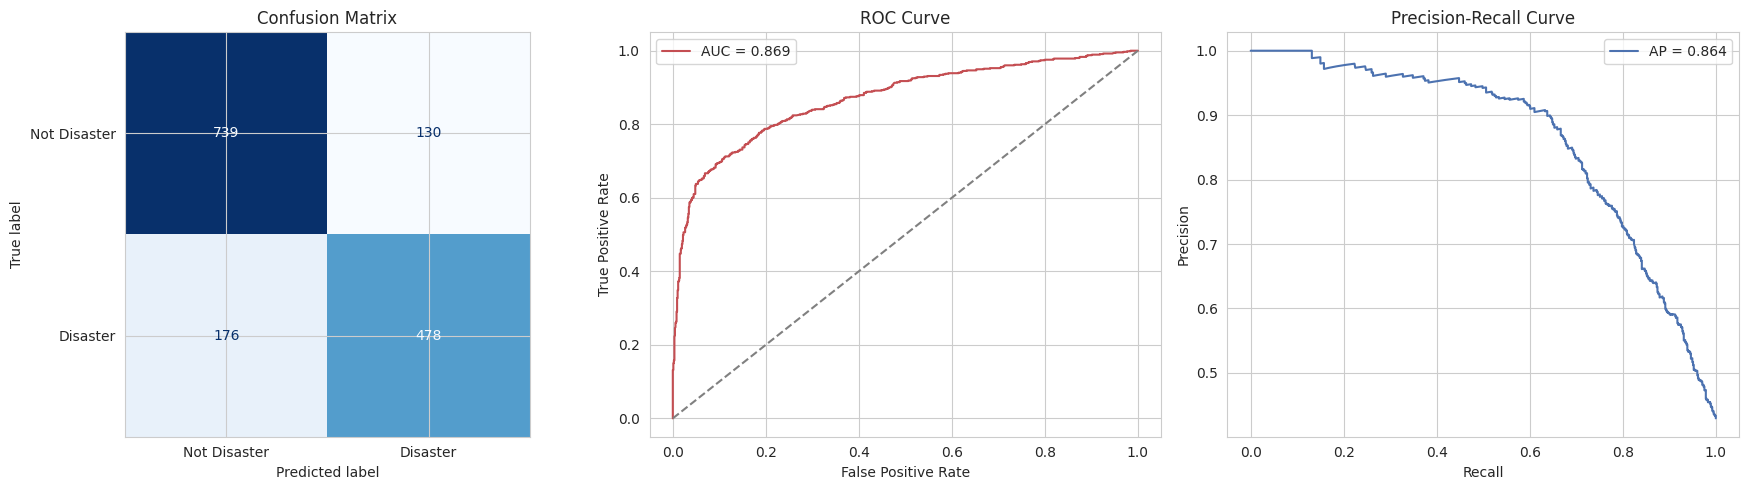

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Disaster', 'Disaster']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC curve
if y_proba.ndim == 1:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#C44E52')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

    # Precision-Recall curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[2].plot(rec_curve, prec_curve, color='#4C72B0', label=f'AP = {ap:.3f}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/evaluation_curves.png', dpi=150)
plt.show()


### 3.1 Overfitting / underfitting check

We compare training-set performance to test-set performance. A large gap (train >> test) would indicate overfitting; poor performance on both would indicate underfitting.


In [ ]:
y_train_pred = best_pipeline.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)
train_acc = accuracy_score(y_train, y_train_pred)

print(f"Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {acc:.4f}")
print(f"Train F1:       {train_f1:.4f}  |  Test F1:       {f1:.4f}")
gap = train_f1 - f1
print(f"\nGeneralization gap (Train F1 - Test F1): {gap:.4f}")
if gap > 0.10:
    print("=> Noticeable overfitting: consider more regularization or fewer TF-IDF features.")
else:
    print("=> Gap is small: the model generalizes well to unseen tweets.")


Train Accuracy: 0.9099  |  Test Accuracy: 0.7991
Train F1:       0.8891  |  Test F1:       0.7575

Generalization gap (Train F1 - Test F1): 0.1315
=> Noticeable overfitting: consider more regularization or fewer TF-IDF features.


### 3.2 Compare all candidate models on the held-out test set (final comparison table)

In [ ]:
final_comparison = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    final_comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds),
    })

final_comparison.append({
    'Model': f'{best_model_name} (Tuned - FINAL)',
    'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1,
})

results_df = pd.DataFrame(final_comparison).sort_values('F1-score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM (SGD),0.806960,0.808219,0.721713,0.762520
1,Multinomial Naive Bayes,0.820749,0.891170,0.663609,0.760736
2,Logistic Regression,0.806960,0.818021,0.707951,0.759016
3,Logistic Regression (Tuned - FINAL),0.799081,0.786184,0.730887,0.757528
4,Random Forest,0.800394,0.861570,0.637615,0.732865


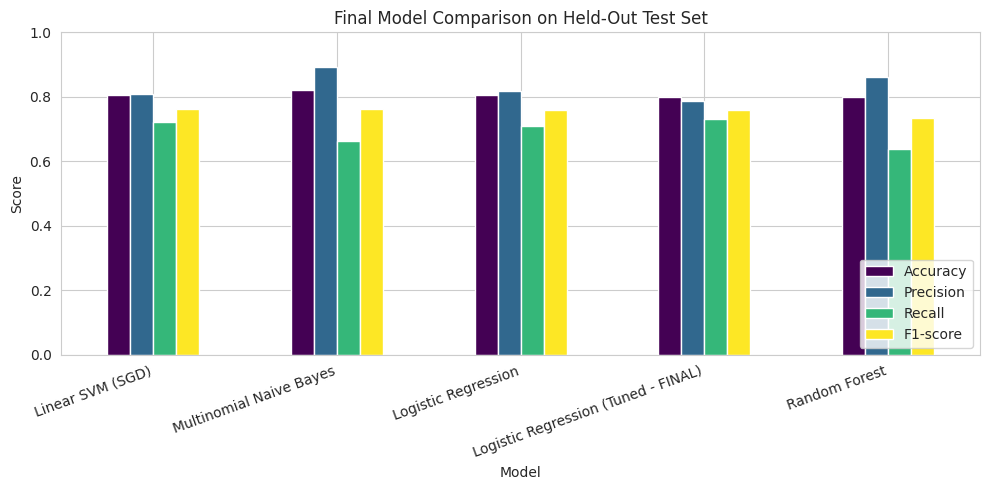

In [ ]:
plt.figure(figsize=(10, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', ax=plt.gca(), colormap='viridis')
plt.title('Final Model Comparison on Held-Out Test Set')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/final_model_comparison.png', dpi=150)
plt.show()

results_df.to_csv('../reports/final_model_comparison.csv', index=False)


### 3.3 Error analysis -- inspect a few misclassified tweets

In [ ]:
test_texts = df.loc[X_test.index, 'text']
errors = pd.DataFrame({
    'text': test_texts,
    'true_label': y_test,
    'predicted_label': y_pred
})
misclassified = errors[errors['true_label'] != errors['predicted_label']]
print(f"Misclassified: {len(misclassified)} / {len(errors)} ({len(misclassified)/len(errors):.1%})")
misclassified.sample(min(10, len(misclassified)), random_state=RANDOM_STATE)


Misclassified: 306 / 1523 (20.1%)


,text,true_label,predicted_label
2056,investigate why Robert mueller didn't respond to my complaints since Nov 2011 &amp; just left me/son out her in dang...,0,1
6689,THIS IS RELAXING! #thunder #SoothMySlumber #WATERMELOANN #populardemand w/ @Soak... (Vine by @thewebbeffect19) https...,0,1
120,#WisdomWed BONUS - 5 Minute Daily Habits that could really improve your life. How many do you already do? #lifehacks...,0,1
4029,I liked a @YouTube video http://t.co/jK7nPdpWRo J. Cole - Fire Squad (2014 Forest Hills Drive),0,1
5800,The last time a high profile name was due to be signing for #nffc the City was rioting! Wesley Verhoek now a househo...,1,0
6488,Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read Û_ http://t.co/nosA8JJjiN...,1,0
3767,This nigga Cyhi diss was what Meek was suppose to do. This shit actually fire,0,1
636,@ONU_France 74/75 Bioterrorism on '@Rockefeller_Chi/@RockefellerUniv'Heiress 2 evade lgl efforts 2 prosecute BLKs 4 ...,0,1
7218,Agreed there - especially on automatic weapons. There's no legitimate reason for needing one @Argus_99 @HeidiA1438,1,0
3749,I See Fire,0,1


These examples illustrate the nuance called out in the project brief: tweets using disaster-related words metaphorically (e.g. sarcasm, jokes, song lyrics) are the hardest cases, and inspecting them helps prioritize future improvements (e.g. adding sarcasm-aware features or a transformer-based model such as BERT for higher context sensitivity).

## Part 4: Deployment Preparation

We serialize the final tuned pipeline (TF-IDF + hand-crafted features + classifier, all in **one** `sklearn.Pipeline` object) with `joblib`, so the exact same preprocessing is guaranteed at inference time. This artifact is loaded by the Flask web application in `/app/app.py`.


In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/disaster_tweet_pipeline.joblib')

# Also persist the clean_text function's logic as a standalone helper file so the Flask
# app can reproduce identical preprocessing on raw user input.
model_card = {
    'best_model_name': f'{best_model_name} (tuned)',
    'best_params': grid.best_params_,
    'test_accuracy': float(acc),
    'test_precision': float(prec),
    'test_recall': float(rec),
    'test_f1': float(f1),
}
import json
with open('../models/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Saved pipeline to ../models/disaster_tweet_pipeline.joblib")
print(json.dumps(model_card, indent=2))


Saved pipeline to ../models/disaster_tweet_pipeline.joblib
{
  "best_model_name": "Logistic Regression (tuned)",
  "best_params": {
    "clf__C": 3.0,
    "prep__tfidf__max_features": 8000,
    "prep__tfidf__ngram_range": [
      1,
      1
    ]
  },
  "test_accuracy": 0.799080761654629,
  "test_precision": 0.7861842105263158,
  "test_recall": 0.7308868501529052,
  "test_f1": 0.757527733755943
}


In [ ]:
# Quick sanity check: load the pipeline back and predict on brand-new example tweets
loaded = joblib.load('../models/disaster_tweet_pipeline.joblib')

def predict_tweet(raw_text):
    cleaned = clean_text(raw_text)
    tokens = tokenize_and_lemmatize(cleaned)
    clean_joined = ' '.join(tokens)
    row = pd.DataFrame([{
        'clean_joined': clean_joined,
        'has_hashtag': int('#' in raw_text),
        'has_mention': int('@' in raw_text),
        'has_url': int(bool(URL_RE.search(raw_text))),
        'exclaim_count': raw_text.count('!'),
        'question_count': raw_text.count('?'),
        'uppercase_word_count': sum(1 for w in raw_text.split() if w.isupper() and len(w) > 1),
        'word_count': len(raw_text.split()),
    }])
    pred = loaded.predict(row)[0]
    return 'DISASTER' if pred == 1 else 'NOT a disaster'

sample_tweets = [
    "Massive earthquake just hit the coast, buildings collapsing everywhere! #earthquake",
    "This new album is fire, absolutely obsessed",
    "Wildfire spreading fast near the highway, evacuation orders issued",
    "OMG that roller coaster was an absolute disaster lmaooo",
]
for t in sample_tweets:
    print(f"[{predict_tweet(t):15s}] {t}")


[DISASTER       ] Massive earthquake just hit the coast, buildings collapsing everywhere! #earthquake
[NOT a disaster ] This new album is fire, absolutely obsessed
[DISASTER       ] Wildfire spreading fast near the highway, evacuation orders issued
[NOT a disaster ] OMG that roller coaster was an absolute disaster lmaooo


## Conclusion

- We explored 7,613 hand-labeled tweets, confirmed a mild class imbalance (57% non-disaster / 43% disaster), and identified that surface keywords alone are not enough to separate literal from metaphorical disaster language.
- We cleaned and normalized the tweet text (lowercasing, URL/mention removal, lemmatization) and engineered a small set of structural features (hashtags, mentions, punctuation intensity).
- We benchmarked four model families with cross-validation, tuned the strongest one with grid search, and validated it on a held-out test set with accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix, plus an overfitting check and manual error analysis.
- The final pipeline is serialized as a single artifact and deployed behind a Flask web interface (see `/app`) that lets a user paste any tweet and get an instant real-disaster / not-a-disaster prediction with a confidence score.

**Possible future improvements:** fine-tune a transformer model (e.g. BERT/DistilBERT via `transformers`) for stronger contextual understanding of sarcasm and metaphor, add geolocation-based features from the `location` column, and set up a live Twitter API stream for true real-time monitoring.
